# Machine Learning
## Programming Assignment 4: Logistic Regression

### Instructions:
The aim of this assignment is to give you hands-on experience with a real-life machine learning application. You will be using Logistic Regression classifier to predict digits based on their drawing.
You can only use the Python programming language and Jupyter Notebooks. Please use procedural programming style and comment your code thoroughly. There are two parts of this assignment. In part 1, you can use NumPy, Pandas, Matplotlib, and any other standard Python libraries. You are not allowed to use NLTK, scikit-learn, or any other machine learning toolkit. You can only use scikit-learn in part 2.

### Part 1: Implementing Logistic Regression classifier from scratch (75 marks)

You are not allowed to use scikit-learn or any other machine learning toolkit for this part. You have to implement your own Logistic Regression classifier from scratch. You may use Pandas, NumPy, Matplotlib, and other standard Python libraries.

#### Problem:
The purpose of this assignment is to get you familiar with the Logistic Regression classification. You are given the ‘MNIST’ dataset that contains around 60000 hand drawn digits. Your task is to implement the Logistic Regression classifier and use it for predicting the digits based on their drawing.


In [1]:
## Here are the libraries you will need for this part/
import pandas as pd
import numpy as np
import scipy.spatial as sc
import matplotlib.pyplot as plt
import re
import random
%matplotlib inline

from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler

#### Task 1.1: Dataset 
The MNIST digits dataset is a widely used benchmark dataset in the field of machine learning and computer vision. MNIST stands for Modified National Institute of Standards and Technology, which is the organization that collected and curated the dataset. The MNIST dataset consists of a collection of 60,000 handwritten digit images for training and an additional 10,000 images for testing. These images are grayscale and have a fixed size of 28x28 pixels. Each image represents a single handwritten digit ranging from 0 to 9.  Each image in the dataset is accompanied by its corresponding label, indicating the digit it represents. The labels are represented as integers from 0 to 9, matching the handwritten digit in the image. This labeling allows for supervised learning tasks, where algorithms can learn to classify and recognize handwritten digits based on the provided training examples.

 Data Shape: (60000, 785)

images shape;  (60000, 784)
labels shape;  (60000,)


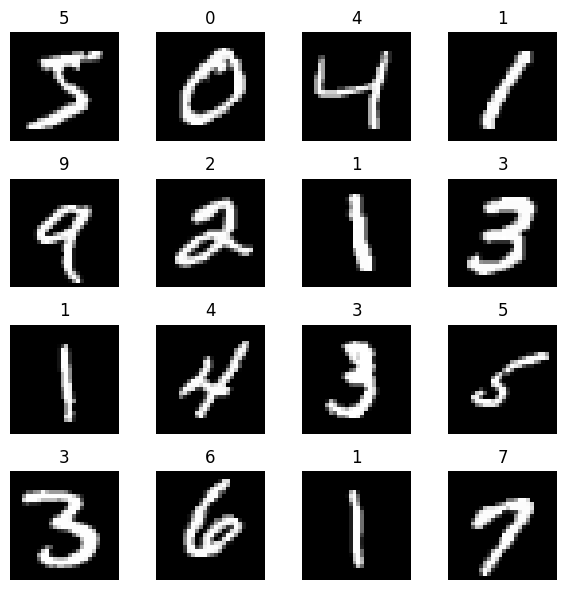

In [2]:
#images_data = np.loadtxt('C:\\mnist_dataset.csv', delimiter = ',' , skiprows = 1)
images_data = pd.read_csv('C:\\mnist_dataset.csv')
print(" Data Shape:", images_data.shape)

labels = images_data['label'].values
images = images_data.drop('label', axis =1).values

print("\nimages shape; ", images.shape)
print("labels shape; ", labels.shape)


fig, axes = plt.subplots(4, 4, figsize = (6,6))

for ax, i in zip(axes.ravel(), range(16)):
    img = images[i].reshape(28,28)
    ax.imshow(img, cmap = 'gray')
    
    ax.set_title(str(labels[i]))
    ax.axis('off')
    
plt.tight_layout()
plt.show()



#### Task 1.2: Data Preprocessing

In the preprocessing step, you’re required to load the data, and scale the values using the StandardScalar function present in scikit-learn

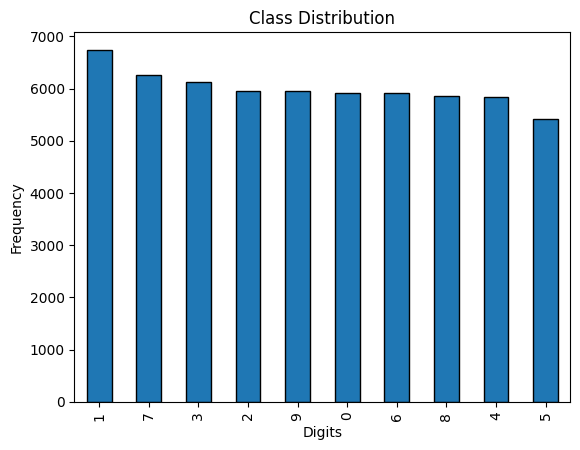

,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,1x10,...,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28,label
count,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,...,6.000000e+04,6.000000e+04,6.000000e+04,6.000000e+04,6.000000e+04,60000.0,60000.0,60000.0,60000.0,60000.000000
mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-4.736952e-18,9.473903e-18,-2.842171e-18,-1.894781e-18,-3.079019e-18,0.0,0.0,0.0,0.0,4.453933
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,1.000008e+00,0.0,0.0,0.0,0.0,2.889270
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-2.246288e-02,-1.606909e-02,-1.143220e-02,-9.007295e-03,-5.770394e-03,0.0,0.0,0.0,0.0,0.000000
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-2.246288e-02,-1.606909e-02,-1.143220e-02,-9.007295e-03,-5.770394e-03,0.0,0.0,0.0,0.0,2.000000
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-2.246288e-02,-1.606909e-02,-1.143220e-02,-9.007295e-03,-5.770394e-03,0.0,0.0,0.0,0.0,4.000000
75%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-2.246288e-02,-1.606909e-02,-1.143220e-02,-9.007295e-03,-5.770394e-03,0.0,0.0,0.0,0.0,7.000000
max,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.418128e+01,8.907405e+01,1.499806e+02,1.513374e+02,1.788764e+02,0.0,0.0,0.0,0.0,9.000000


In [3]:
counts = images_data['label'].value_counts()
counts.plot(kind='bar', edgecolor='black',)

plt.xlabel('Digits')
plt.ylabel('Frequency')
plt.title('Class Distribution')

plt.show()

X = images_data.drop(columns = ['label'])
y = images_data['label']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_images_data = pd.DataFrame(X_scaled, columns = X.columns)

data = pd.concat([X_scaled_images_data, y], axis = 1)
data.describe()

#### Task 1.3: Splitting the dataset

In this part, divide the given dataset into training and testing sets using python.
Print out the sizes of the training dataset and test dataset, training data should contain 50000 images and test data should contain 10000 images. If your sizes are correct, you get full points.

In [4]:
# shuffling the dataset

data = data.sample(frac=1, random_state=42).reset_index(drop=True)

# slicing
train_data = data.iloc[:50000]
test_data = data.iloc[50000:]

# spliting features and labels
train_X = train_data.drop(columns = ['label'])
train_y = train_data['label']

test_X = test_data.drop(columns=['label'])
test_y = test_data['label']

train_X = train_X.to_numpy()
train_y = train_y.to_numpy()


print("train_X.shape", train_X.shape)
print("train_y.shape", train_y.shape)
print("test_X.shape", test_X.shape)
print("test_y.shape", test_y.shape)

train_X.shape (50000, 784)
train_y.shape (50000,)
test_X.shape (10000, 784)
test_y.shape (10000,)


#### Task 1.4: Create Logistic Regression classifier 

Implement Multinomial Logistic Regression from scratch keeping in view all the discussions
from the lectures to classify the images into the 10 classes specified. Specifically, you’ll need to implement the
following: <br>
● Softmax function <br>
● Cross-entropy loss function (for multinomial logistic regression) <br>
● Batch Gradient Descent <br>
● Prediction function that predicts the label of test recordings using learned
multinomial logistic regression

In [5]:
# one vs all logistic regression classifier

# function to modify the dataset

def convert_dataset(train_y, test_y, label):
    train_y = np.where(train_y == label, 1, 0)
    test_y = np.where(test_y == label, 1, 0)
    return train_y, test_y

# example
train_1_y, test_1_y = convert_dataset(train_y, test_y, 1)
print(train_1_y[:100])



[0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0]


In [8]:
print(train_y[:100])

[7 3 8 9 3 9 7 7 5 4 2 5 6 8 1 7 4 8 0 7 9 3 1 7 6 5 3 3 3 6 0 8 4 9 5 1 8
 7 8 8 0 8 2 0 8 5 5 2 2 0 1 5 9 3 0 6 2 2 6 4 0 1 8 4 0 2 4 7 7 4 4 0 1 4
 8 6 0 0 0 9 6 3 6 9 9 4 8 6 6 1 9 5 2 6 3 4 9 1 0 4]


In [9]:
# model class

class OvALogisticReg:
    def __init__(self, num_classes, num_features, learning_rate = 0.01, epochs = 1000):
        
        self.num_classes = num_classes
        self.num_features = num_features
        self.learning_rate = learning_rate
        self.epochs = epochs
        
        self.weights = np.zeros((num_classes, num_features))
        self.biases = np.zeros(num_classes)
        
    def sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1/(1+ np.exp(-z))
    
    def softmax(self, z):
        return np.exp(z) / np.sum(np.exp(z))
    
    def cross_entropy_loss(self, y_true, y_prob):
        eps = 1e-12
        y_prob = np.clip(y_prob, eps, 1-eps)
        return -np.mean(y_true * np.log(y_prob) + (1-y_true) * np.log(1 - y_prob))
        
    def fit(self, train_X, train_y):
        X = train_X.to_numpy() if hasattr(train_X, "to_numpy") else train_X
        y = train_y.to_numpy() if hasattr(train_y, "to_numpy") else train_y
        
        n = X.shape[0]

        for label in range(self.num_classes):
            #OvA: build binary ttargets for this class
            y_bin = (y == label).astype(float)
            
            # optional random init
            self.weights[label] = np.random.randn(self.num_features) * 0.01
            self.biases[label] = 0.0
            
            for epoch in range(self.epochs):
                # logits
                logits = X @ self.weights[label] + self.biases[label]
                
                # probs
                probs = self.sigmoid(logits)
                
                # loss
                loss = self.cross_entropy_loss(y_bin, probs)
                
                # gradients
                error = probs - y_bin
                weight_gradient = (X.T @ error) / n
                bias_gradient = np.mean(error)
                
                #update weights
                self.weights[label] -= self.learning_rate * weight_gradient
                self.biases[label] -= self.learning_rate * bias_gradient
                
                #print(f"Epoch {epoch+1}/{self.epochs}, loss: {loss}")

    def predict(self, test_X):
        if hasattr(test_X, "to_numpy"):
            X = test_X.to_numpy()
        else:
            X = test_X
        
        logits = X @ self.weights.T + self.biases
        probs = self.sigmoid(logits)
        
        # OvA prediction: choose class with highest prob
        return np.argmax(probs, axis=1)
    

#### Task 1.5: Implement evaluation functions

Implement evaluation functions that calculates the:
- classification accuracy,
- F1 score,
- and the confusion matrix
of your classifier on the test set.


In [10]:
def classification_accuracy(y_true, y_pred):
    return float(np.mean(y_true == y_pred))

def confusion_matrix(y_true, y_pred, num_classes):
    cm = np.zeros((num_classes, num_classes), dtype = int)
    
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    
    return cm

def f1_score(y_true, y_pred, num_classes):
    
    cm = confusion_matrix(y_true, y_pred, num_classes)
    
    f1_scores = []
    
    for k in range(num_classes):
        TP = cm[k, k]
        FP = np.sum(cm[:, k]) - TP
        FN = np.sum(cm[k, :]) - TP
        
        # avoid division by zero
        precision = TP / (TP + FP) if (TP + FP) != 0 else 0.0
        recall = TP / (TP + FN) if (TP + FN) != 0 else 0.0
        
        if precision == 0 and recall == 0:
            f1 = 0
        else:
            f1 = 2 * precision * recall / (precision + recall)
            
        f1_scores.append(f1)
         
    macro_f1 = float(np.mean(f1_scores)) 
    
    return f1_scores, macro_f1  
         

#Evaluation Example

In [25]:
model = OvALogisticReg(num_classes= 10, num_features= 784)

model.fit(train_X, train_y)

y_pred = model.predict(test_X)

accuracy = classification_accuracy(test_y, y_pred)
cm = confusion_matrix(test_y, y_pred, 10)
f1_per_class, macro_f1 = f1_score(test_y, y_pred, 10)	


f1_per_class = [float(x) for x in f1_per_class]

for i, score in enumerate(f1_per_class):
    print(f"F1 Class {i}: {score:.4f}")

print("\n Macro F1: ",macro_f1)
print("\n Accuracy: ",accuracy)
print("\n Confusion Matrix: \n",cm)



F1 Class 0: 0.9355
F1 Class 1: 0.8913
F1 Class 2: 0.8495
F1 Class 3: 0.8387
F1 Class 4: 0.8721
F1 Class 5: 0.8278
F1 Class 6: 0.9014
F1 Class 7: 0.8840
F1 Class 8: 0.8268
F1 Class 9: 0.8272

 Macro F1:  0.8654245895751599

 Accuracy:  0.8674

 Confusion Matrix: 
 [[ 935    0    4    2    2    7   13    1    6    1]
 [   1 1128    5    1    4    3    3    4   10    0]
 [  15   47  821   17   18    1   42   20   27    8]
 [   4   27   35  801    4   23    8   21   20   16]
 [   2   22    8    0  852    9    7    4    8   42]
 [  20   10    4   66   20  697   27    6   32   15]
 [  24   17   17    1   12   17  928    0    3    0]
 [   6   29    7    4   13    0    1  930    1   47]
 [  12   83   13   33   15   27   11    7  785   19]
 [   9    9    3   26   60    3    0   73    2  797]]


#### Task 1.6: Cross Validation 

Use 5- fold cross-validation on your training data. (In cross-validation, you divide the training data set into 5 parts. 4 parts will be used for training and 1 part will be used for validation. Then you will take a different part of your data as a validation data set and train your algorithm on the rest of the data set.) Run your Logistic Regression function for this data for 5 learning rate values ranging from 0.001 and 0.01.

Run your evaluation function for each value of the learning rate, Report classification accuracy, F1 score, and confusion matrix.

Present the results as a graph with learning rate values on the x-axis and classification accuracy on the y-axis. Make another graph but with the F1 score on the y-axis this time. The graphs should be properly labelled.

In [111]:
def kfold_indices(n_samples, k = 5, shuffle = True, seed =42):
    idx = np.arange(n_samples)
    if shuffle:
        np.random.seed(seed)
        np.random.shuffle(idx)
        
    folds = np.array_split(idx, k)
    for i in range(k):
        val_idx = folds[i]
        train_idx = np.concatenate([folds[j] for j in range(k) if j != i])
        yield train_idx, val_idx
    
def run_5fold_cv(train_X, train_y, learning_rates, num_classes=10, epochs=200, seed=42):
    n = train_X.shape[0]
    results = {}

    # detect pandas vs numpy
    is_pandas_X = hasattr(train_X, "iloc")
    is_pandas_y = hasattr(train_y, "iloc")

    for lr in learning_rates:
        fold_accs = []
        fold_f1s = []
        fold_cms = []

        for fold, (tr_idx, va_idx) in enumerate(kfold_indices(n, k=5, shuffle=True, seed=seed), start=1):

            if is_pandas_X:
                X_tr = train_X.iloc[tr_idx].to_numpy()
                X_va = train_X.iloc[va_idx].to_numpy()
            else:
                X_tr = train_X[tr_idx]
                X_va = train_X[va_idx]

            if is_pandas_y:
                y_tr = train_y.iloc[tr_idx].to_numpy()
                y_va = train_y.iloc[va_idx].to_numpy()
            else:
                y_tr = train_y[tr_idx]
                y_va = train_y[va_idx]

            model = OvALogisticReg(
                num_classes=num_classes,
                num_features=X_tr.shape[1],
                learning_rate=float(lr),
                epochs=epochs
            )

            model.fit(X_tr, y_tr)
            y_pred = model.predict(X_va)

            fold_acc = classification_accuracy(y_va, y_pred)
            f1_scores, macro_f1 = f1_score(y_va, y_pred, num_classes)
            fold_cm = confusion_matrix(y_va, y_pred, num_classes)

            fold_accs.append(fold_acc)
            fold_f1s.append(macro_f1)
            fold_cms.append(fold_cm)

            print(f"[lr={lr:.4f}] Fold {fold}: Acc={fold_acc:.4f}, MacroF1={macro_f1:.4f}")

        results[float(lr)] = {
            "acc": float(np.mean(fold_accs)),
            "f1": float(np.mean(fold_f1s)),
            "conf_mat": np.sum(fold_cms, axis=0)
        }

        print(f"[lr={lr:.4f}] Average Acc={results[float(lr)]['acc']:.4f}, "
              f"Average MacroF1={results[float(lr)]['f1']:.4f}\n")

    return results
             

In [82]:
# run for 5 earning rates
learning_rates = np.linspace(0.001, 0.01, 5)

cv_results = run_5fold_cv(train_X, train_y, learning_rates, num_classes = 10, epochs = 1000, seed =42)

for lr in learning_rates:
    r = cv_results[float(lr)]
    print(f"Learning rate: {lr:.4f} | Accuracy={r['acc']:.4f} | MacroF1={r['f1']:.4f}")
    print("Confusion Matrix:")
    print(r["conf_mat"])
    print("-"*60)

[lr=0.0010] Fold 1: Acc=0.8229, MacroF1=0.8183
[lr=0.0010] Fold 2: Acc=0.8214, MacroF1=0.8155
[lr=0.0010] Fold 3: Acc=0.8261, MacroF1=0.8228
[lr=0.0010] Fold 4: Acc=0.8199, MacroF1=0.8157
[lr=0.0010] Fold 5: Acc=0.8269, MacroF1=0.8220
[lr=0.0010] Average Acc=0.8234, Average MacroF1=0.8189

[lr=0.0033] Fold 1: Acc=0.8439, MacroF1=0.8403
[lr=0.0033] Fold 2: Acc=0.8412, MacroF1=0.8370
[lr=0.0033] Fold 3: Acc=0.8476, MacroF1=0.8448
[lr=0.0033] Fold 4: Acc=0.8444, MacroF1=0.8413
[lr=0.0033] Fold 5: Acc=0.8476, MacroF1=0.8436
[lr=0.0033] Average Acc=0.8449, Average MacroF1=0.8414

[lr=0.0055] Fold 1: Acc=0.8531, MacroF1=0.8500
[lr=0.0055] Fold 2: Acc=0.8498, MacroF1=0.8462
[lr=0.0055] Fold 3: Acc=0.8563, MacroF1=0.8538
[lr=0.0055] Fold 4: Acc=0.8533, MacroF1=0.8509
[lr=0.0055] Fold 5: Acc=0.8557, MacroF1=0.8524
[lr=0.0055] Average Acc=0.8536, Average MacroF1=0.8507

[lr=0.0078] Fold 1: Acc=0.8580, MacroF1=0.8552
[lr=0.0078] Fold 2: Acc=0.8563, MacroF1=0.8530
[lr=0.0078] Fold 3: Acc=0.8641, M

Graph - Accuracy vs Learning Rate

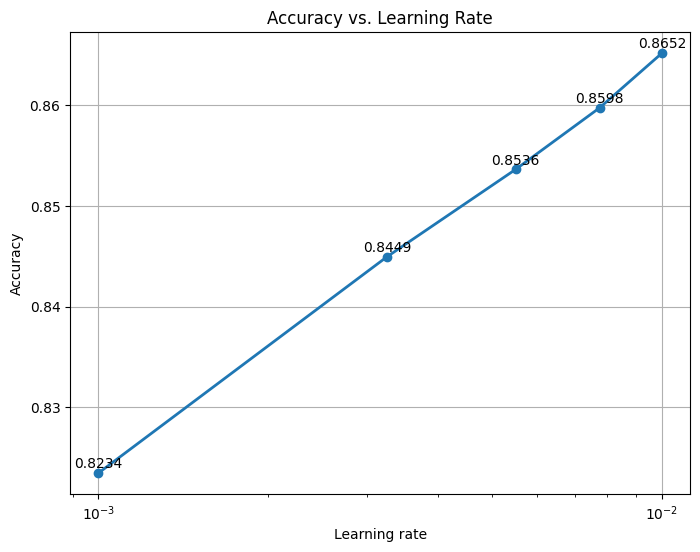

In [90]:
# sort learning rates for clean plotting
lrs = sorted(cv_results.keys())

# extract accuracies
accuracies = [cv_results[lr]["acc"] for lr in lrs]

plt.figure(figsize=(8,6))
plt.plot(lrs, accuracies, marker='o', linewidth=2)

for i, val in enumerate(accuracies):
    plt.text(lrs[i], val + 0.0005, f"{val:.4f}", ha = 'center')
    
plt.xscale('log')
plt.xlabel('Learning rate')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. Learning Rate')
plt.grid(True)
plt.show()

Graph - Macro F1 vs Learning Rate

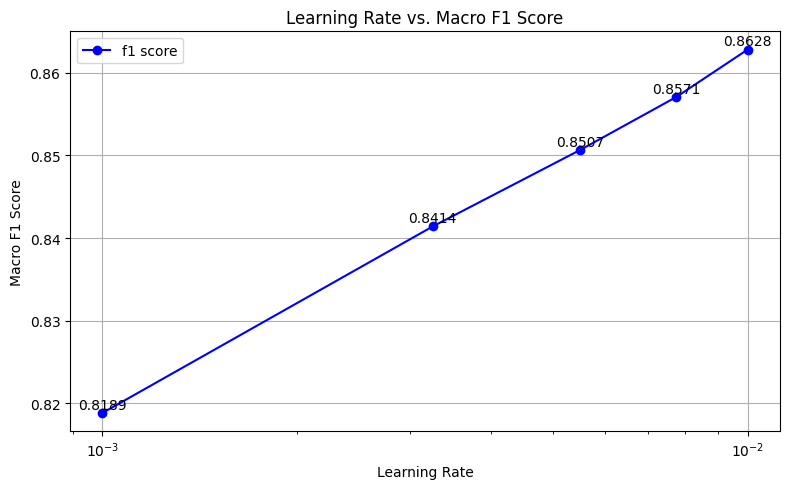

In [116]:
f1_scores_list = [cv_results[lr]["f1"] for lr in lrs]

plt.figure(figsize=(8, 5))
plt.plot(lrs, f1_scores_list, color="blue", marker="o", linestyle="-", label="f1 score")
plt.xscale("log")

for i, val in enumerate(f1_scores_list):
    plt.text(lrs[i], val + 0.0005, f"{val:.4f}", ha='center')

plt.xlabel("Learning Rate")
plt.ylabel("Macro F1 Score")
plt.title("Learning Rate vs. Macro F1 Score")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


#### Task 1.7: Classification

Finally, use the best value of the learning rate and run it on the test data set. Find the F1 score, classification accuracy, and confusion matrix and print them.

You accuracy should be above 80 and f1 score should be above 70 to get full points.

In [117]:
# picking best learning rate
best_lr = max(cv_results.keys(), key=lambda lr: cv_results[lr]["acc"])

print("Best learning Rate from CV:", best_lr)
print("Best accuracy:", cv_results[best_lr]["acc"])
print("Best Macro F1:", round(cv_results[best_lr]["f1"],4))

Best learning Rate from CV: 0.01
Best accuracy: 0.8652
Best Macro F1: 0.8628


In [103]:
#Train final model

# convert to numpy pandas
X_train = train_X.to_numpy() if hasattr(train_X, "to_numpy") else train_X

y_train = train_y.to_numpy() if hasattr(train_y, "to_numpy") else train_y

X_test = test_X.to_numpy() if hasattr(test_X, "to_numpy") else test_X

y_test = test_y.to_numpy() if hasattr(test_y, "to_numpy") else test_y

final_model = OvALogisticReg(num_classes = 10, num_features = X_train.shape[1], learning_rate = float(best_lr), epochs = 1000)

final_model.fit(X_train, y_train)
y_pred_test = final_model.predict(X_test)

#

In [ ]:
# Evaluate on TEST set (Accuracy, F1, Confusion Matrix)	

test_acc = classification_accuracy(y_test, y_pred_test)

f1_scores_test, macro_f1_test = f1_score(y_test, 

y_pred_test, num_classes = 10)

cm_test = confusion_matrix(y_test, y_pred_test, num_classes = 10)

print("-- Final TEST set results --")

print(f"Best Learning Rate : {best_lr}")
print(f"\nTest Accuracy : {test_acc}")
#print(f"Test F1 Score : {f1_scores_test}")
print(f"\nTest Macro F1 Score : {macro_f1_test}")
print(f"\nTest Confusion Matrix :\n \n{cm_test}")

-- Final TEST set results --
Best LR Used : 0.01

Test Accuracy : 0.8659

Test Macro F1 Score : 0.8636202653967835

Test Confusion Matrix :
 
[[ 934    2    8    2    4    4   12    1    6    1]
 [   0 1089    9    5    1    6    1    1    9    0]
 [  16   33  822   13    7    3   38   15   26    2]
 [  10   16   33  887    5   23    7   30   19   13]
 [   2   18    9    0  942    3   11    6    9   46]
 [  33   17    6   59   19  685   33   10   39   19]
 [  21    7   11    0    7   17  858    0    2    1]
 [  10   31    6    7   19    4    0  920    1   33]
 [  14   86   13   42   16   37   12    8  738   24]
 [  10   11    5   14   47    3    0   91   11  784]]


### Part 2:  Logistic Regression classifier using scikit-learn

Use scikit-learn’s Logistic Regression implementation to train and test the logistic regression
on the provided dataset. Use scikit-learn’s accuracy_score function to calculate the accuracy
and confusion_matrix function to calculate confusion matrix on the test set.
To get full marks, the accuracy score, classification reports and confusion matrix must be shown for values for accuracy and F1 should be similar to those obtained in the previous part.

In [132]:
# Here are the libraries and specific functions you will be needing for this part

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score as sk_f1_score

In [140]:
clf = LogisticRegression(
	
	C = 1.0,
 	max_iter = 200
 	
 )
clf.fit(X_train, y_train)

# predictions
y_pred = clf.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

#f1 score
macro_f1 = sk_f1_score(y_test, y_pred, average='macro')


#Classification Report
report = classification_report(y_test, y_pred)

print("\n-- sklearn Logistic Regression --")
print("\nAccuracy: ", accuracy)
print("Macro F1 score: ", round((macro_f1),4))
print("\nConfusion Matrix: ")
print(cm)
#print("\nClassification Report: ")
#print(report)


-- sklearn Logistic Regression --

Accuracy:  0.9129
Macro F1 score:  0.9118

Confusion Matrix: 
[[ 927    0    3    1    2   16   12    5    7    1]
 [   0 1092    9    2    1    4    0    2   10    1]
 [   3   12  887   12    6    8   15    8   23    1]
 [   7    2   25  932    3   31    8    7   19    9]
 [   6    4    7    2  955    3   13    6    6   44]
 [  17    6    9   21   11  797   21    4   23   11]
 [   8    2    9    2    8   15  874    1    5    0]
 [   2    4   11    7   11    4    0  951    2   39]
 [  10   24   13   27    8   28   10    3  847   20]
 [   8    6    1    9   23   12    0   38   12  867]]


The One vs All logistic regression model developed from scratch achieved a test accuracy of 86.59 percent and a macro F1 score of 0.8636. By contrast, scikit learn’s optimized LogisticRegression model demonstrated superior performance, attaining 91.29 percent accuracy and a macro F1 score of 0.9118. The observed improvement is likely due to the library’s advanced optimization procedures, built in L2 regularization, and greater numerical stability during convergence. In addition, the confusion matrices suggest that the scikit learn model was more effective in reducing misclassifications between visually similar digit classes, most notably 7 and 9, as well as 3 and 8.